# Where does the population go? Per-m leakage map of the RID 76695 symmetric MZ

This notebook projects the atom onto the momentum/internal-state basis **after
every pulse** of the genuine ARTIQ RID 76695 symmetric Mach-Zehnder
(`DeclarativeLMTGlobalSymmetricMachZehnderFrag`) and plots the resulting
populations, so we can see exactly where population leaks out of the intended
interferometer path as the sequence progresses.

**Readout convention.** The "probability of finding the atom in `(m, internal)`
if we projected right now" is the sim's own projective-measurement quantity,
`calculate_ground_and_excited_probabilities`: for each momentum class `m` the
amplitudes of all rows sharing `(m, internal)` are summed **coherently** and
squared,

$$P_\text{g}(m) = \Bigl|\sum_{\text{rows: }m,\,g} c\Bigr|^2, \qquad
  P_\text{e}(m) = \Bigl|\sum_{\text{rows: }m,\,e} c\Bigr|^2 .$$

This is frame-independent (all rows of one `(m, internal)` carry the same
Bordé-frame phase) and it is what a real clearout / detection would measure.
Because it is coherent, these populations genuinely reflect interference
between paths that recombine into the same `m`.

**Interferometry phase.** Set to **zero** here (`interferometer_phase = 0`):
pulses 10-18 would otherwise carry `φ` and pulse 19 `4φ` (the scanned MZ
phase), but for a *leakage* diagnostic the zero-phase configuration is the
clean baseline. Only the final recombination (last couple of pulses) depends
on the scan phase; the leakage during the mirror train does not.

**No clearouts.** The raw pulse sequence is run with no 461 nm clearouts, so
every bit of leaked population stays visible instead of being thrown away --
that is the point of the diagnostic.

In [1]:
import sys

sys.path.insert(0, "..")

import warnings
import dataclasses

import numpy as np
import matplotlib.pyplot as plt

import lmt_sim.lmt_sequence as seq
import lmt_sim.lmt_simulation as sim

## The RID 76695 pulse dump (interferometer_phase = 0 point)

Genuine float64 SI `pulse_record_flat` as emitted by `PulseDMARecording`. The
8th row (per-pulse interferometry phase) is all zeros at this scan point.

In [2]:
pulse_record_flat = np.array(
    [
        20.0,
        1.0,
        0.0,
        1.0,
        1.0,
        0.0,
        0.0,
        0.0,
        0.0,
        1.0,
        1.0,
        0.0,
        1.0,
        1.0,
        0.0,
        0.0,
        0.0,
        0.0,
        1.0,
        1.0,
        0.0,
        0.0011392000000000002,
        0.002142592,
        0.002231312,
        0.0025090480000000003,
        0.0026367680000000003,
        0.0027254880000000003,
        0.002864208,
        0.0031529440000000004,
        0.003291664,
        0.003369384,
        0.0034496320000000002,
        0.0035383520000000003,
        0.003816088,
        0.003943808,
        0.0040325280000000005,
        0.004171248000000001,
        0.004459984,
        0.004598704,
        0.004676424,
        0.004756672,
        0.000379999,
        6.7e-05,
        5.5999000000000004e-05,
        5.5999000000000004e-05,
        6.7e-05,
        6.7e-05,
        6.7e-05,
        6.7e-05,
        5.5999000000000004e-05,
        5.5999000000000004e-05,
        6.7e-05,
        5.5999000000000004e-05,
        5.5999000000000004e-05,
        6.7e-05,
        6.7e-05,
        6.7e-05,
        6.7e-05,
        5.5999000000000004e-05,
        5.5999000000000004e-05,
        6.7e-05,
        80014038.33602092,
        79984442.05274647,
        80009610.08426937,
        80032313.77748647,
        79996307.57957408,
        79957453.70680287,
        79993114.16819608,
        79951451.93554893,
        80024498.14328054,
        80044393.47662166,
        79966090.32742324,
        80027961.8095926,
        80050665.50280967,
        79977955.85425085,
        79939101.98147964,
        79974762.44287285,
        79933100.2102257,
        80042849.86860377,
        80062745.20194489,
        79947738.60210001,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        200000000.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        99426200.0,
        0.012,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        2.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
        0.0,
    ]
)
pulse_record_offsets = np.array([0], dtype=np.int64)

dump = seq.decode_pulse_record_flat(pulse_record_flat, pulse_record_offsets)[0]
n_pulses = len(dump.is_up)
print(f"decoded {n_pulses} pulses; up/down = {dump.is_up.sum()}/{(~dump.is_up).sum()}")

decoded 20 pulses; up/down = 9/11


## Build the sequence (calibrated, phase = 0, no clearouts)

`calibrate_probe_shift_and_velocity_from_dump` reverse-engineers the AC-Stark
coefficient and initial velocity that put every recorded pulse on its intended
recoil rung (a self-consistent fit -- it warns loudly; suppressed here for
readability). The build then folds the free-fall Doppler shift into the
recorded detunings, so the quantum run is done at v = 0.

In [3]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    alpha, v0 = seq.calibrate_probe_shift_and_velocity_from_dump(
        **dataclasses.asdict(dump)
    )
print(f"probe-shift alpha = {alpha:.4g} 1/Hz   initial velocity = {v0 * 1e3:+.3f} mm/s")

_timestamps, sequence = seq.build_sequence_from_lab_pulse_dump(
    **dataclasses.asdict(dump),
    probe_induced_alpha_up=alpha,
    probe_induced_alpha_down=alpha,
    initial_velocity_z=v0,
)
pulse_events = [e for e in sequence if isinstance(e, seq.Pulse)]
assert len(pulse_events) == n_pulses

probe-shift alpha = -1.708e-05 1/Hz   initial velocity = -0.034 mm/s


## Project after every pulse

`iter_pulse_sequence_in_borde_representation` yields the state before the first
event and after every event. We keep the snapshot taken immediately after each
`Pulse` (free-fall between pulses does not change the `(m, internal)`
populations, only their phases and positions), giving one momentum spectrum per
pulse index 0..19.

In [4]:
def coherent_populations_by_m(state):
    """Return {m: P_ground(m)}, {m: P_excited(m)} using the coherent per-m sum."""
    p_ground, p_excited = {}, {}
    for m in np.unique(state.m_values):
        same_m = state.m_values == m
        g = same_m & state.internal_is_ground
        e = same_m & ~state.internal_is_ground
        p_ground[int(m)] = float(np.abs(state.amplitudes[g].sum()) ** 2)
        p_excited[int(m)] = float(np.abs(state.amplitudes[e].sum()) ** 2)
    return p_ground, p_excited


# Snapshot after every event, then keep the ones that follow a Pulse.
initial = sim.make_atom_states(c0=1, c1=0, initial_velocity_z=0.0)
snapshots = list(
    seq.iter_pulse_sequence_in_borde_representation(
        initial, sequence, initial_velocity_z=0.0, discard_threshold=1e-12
    )
)
# snapshots[0] is the initial state; snapshots[i + 1] is after sequence[i].
per_pulse_ground = []
per_pulse_excited = []
for i, event in enumerate(sequence):
    if isinstance(event, seq.Pulse):
        state = snapshots[i + 1][0]
        pg, pe = coherent_populations_by_m(state)
        per_pulse_ground.append(pg)
        per_pulse_excited.append(pe)

assert len(per_pulse_ground) == n_pulses

# Assemble dense (n_pulses x n_m) probability matrices on a shared m-grid.
all_m = sorted({m for d in (per_pulse_ground + per_pulse_excited) for m in d})
m_index = {m: j for j, m in enumerate(all_m)}
ground_mat = np.zeros((n_pulses, len(all_m)))
excited_mat = np.zeros((n_pulses, len(all_m)))
for p in range(n_pulses):
    for m, val in per_pulse_ground[p].items():
        ground_mat[p, m_index[m]] = val
    for m, val in per_pulse_excited[p].items():
        excited_mat[p, m_index[m]] = val

total_per_pulse = ground_mat.sum(axis=1) + excited_mat.sum(axis=1)
print(f"m classes populated across the sequence: {all_m[0]} .. {all_m[-1]}")
print(
    f"total projected probability per pulse: min {total_per_pulse.min():.3f}, "
    f"max {total_per_pulse.max():.3f} (coherent readout conserves probability)"
)

m classes populated across the sequence: -5 .. 9
total projected probability per pulse: min 1.000, max 1.000 (coherent readout conserves probability)


## The leakage map -- populations by m, swept pulse by pulse

Two panels (ground, excited). **x = momentum class m, y = projection
probability.** One line per pulse, coloured from dark (early pulses) to bright
(late pulses), so you can watch population get pumped up the recoil ladder and
see where it spills into unintended classes.

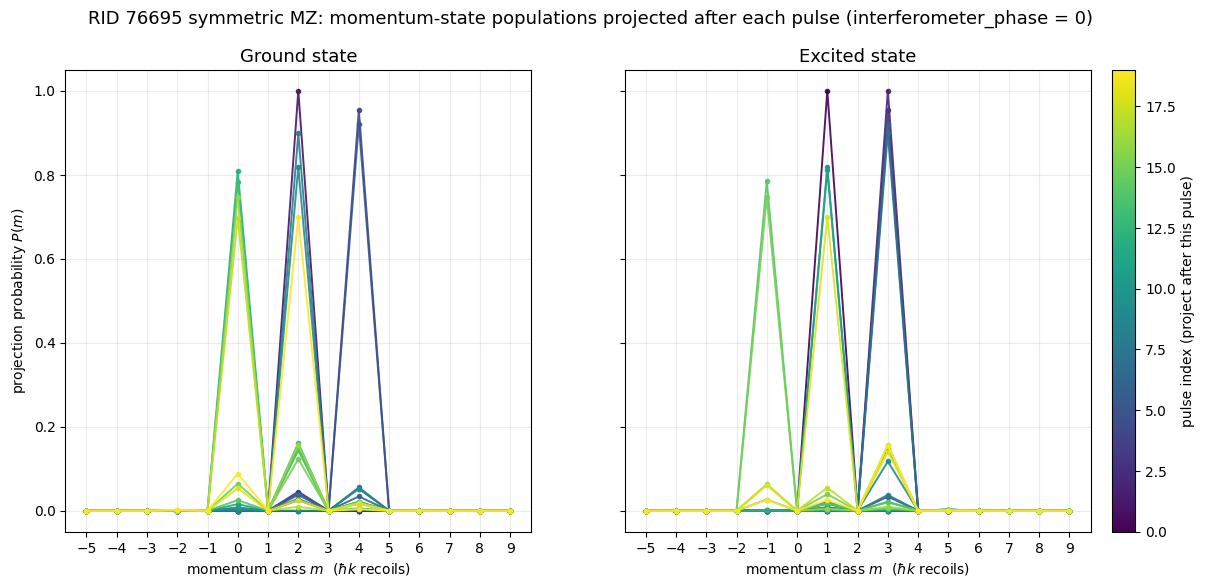

In [5]:
m_arr = np.array(all_m)
cmap = plt.get_cmap("viridis")
colors = [cmap(p / (n_pulses - 1)) for p in range(n_pulses)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
for ax, mat, title in (
    (axes[0], ground_mat, "Ground state"),
    (axes[1], excited_mat, "Excited state"),
):
    for p in range(n_pulses):
        ax.plot(m_arr, mat[p], color=colors[p], lw=1.4, marker="o", ms=3, alpha=0.9)
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("momentum class $m$  ($\\hbar k$ recoils)")
    ax.grid(alpha=0.25)
    ax.set_xticks(m_arr)
axes[0].set_ylabel("projection probability $P(m)$")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=n_pulses - 1))
cbar = fig.colorbar(sm, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label("pulse index (project after this pulse)")
fig.suptitle(
    "RID 76695 symmetric MZ: momentum-state populations projected after each pulse "
    "(interferometer_phase = 0)",
    fontsize=13,
)
plt.show()

## Same data as heatmaps

A complementary view: pulse index on the vertical axis, momentum on the
horizontal, colour = projection probability. Rows read top-to-bottom as the
sequence advances; bright horizontal streaks are where population parks.

The colour is on a **logarithmic** scale so the weak parasitic paths -- the
few-times-$10^{-3}$ population that off-resonant transfer spills into
unintended `m` classes -- are visible alongside the near-unity main streak. A
linear scale washes them out entirely. Probabilities below ``FLOOR`` (and the
exact zeros) are clipped to the darkest colour.

## Intended interferometer path (overlaid to guide the eye)

The next figure overlays the **intended** Mach-Zehnder arm trajectories on the
leakage heatmap. The intended path is found by walking an ideal on-axis atom
through the sequence, letting each pulse **flip**, **drift**, or **split** by
its Rabi area (the `compute_spacetime_trajectory` rule): a π pulse flips, a π/2
pulse splits.

**The catch for this RID:** the two beamsplitters `bs1`/`bs2` were *designed*
as π/2 but the global-mode duration bug fired them as full **π** — so if we
walked the *recorded* sequence they would flip rather than split, and there
would be no interferometer to draw. To show what the sequence was *meant* to
do, we force those two pulses back to a π/2 duration
(`force_bs_pi2=True`) before tracing the intended path. The overlaid arms are
therefore the interferometer the lab intended; comparing them with the actual
(all-π) population underneath shows the damage: the recorded π at `bs1` drives
the whole cloud down **one** intended arm (that arm's rings sit on bright
cells), while the **other** intended arm's rings sit over dark cells —
population that a real π/2 split would have created but never did.

In [6]:
def intended_arm_trajectories(dump, force_bs_pi2, flip_threshold=0.75):
    """Intended MZ arms: list of dicts {pulse_index: (m, is_ground)}.

    Walks an ideal on-axis atom through the sequence, splitting at π/2 and
    flipping at π (the `compute_spacetime_trajectory` rule). If ``force_bs_pi2``
    the two beamsplitters (pulses 1 and n-1) are set to a down-π/2 duration
    first, so the intended split is shown even for this record, in which they
    fired as full π.
    """
    d = dump
    n = len(d.is_up)
    if force_bs_pi2:
        dur = np.array(d.durations_s)
        for b in (1, n - 1):
            dur[b] = 33.5e-6  # down-π/2 = half the 67 µs down-π
        d = dataclasses.replace(d, durations_s=dur)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        alpha, v0 = seq.calibrate_probe_shift_and_velocity_from_dump(
            **dataclasses.asdict(d)
        )
    _t, sequence = seq.build_sequence_from_lab_pulse_dump(
        **dataclasses.asdict(d),
        probe_induced_alpha_up=alpha,
        probe_induced_alpha_down=alpha,
        initial_velocity_z=v0,
    )
    pulses = [e for e in sequence if isinstance(e, seq.Pulse)]
    arms = [{"m": 0, "g": True, "hist": {}, "cid": 0}]
    first_split_done = False
    for p, pl in enumerate(pulses):
        nxt = []
        for a in arms:
            pr = seq._transition_probability(a["m"], a["g"], pl)
            if pr >= flip_threshold:
                a["m"] += pl.k if a["g"] else -pl.k
                a["g"] = not a["g"]
                a["hist"][p] = (a["m"], a["g"])
                nxt.append(a)
            elif pr <= 1 - flip_threshold:
                a["hist"][p] = (a["m"], a["g"])
                nxt.append(a)
            else:  # π/2 → split into a drifter and a flipper
                # The input splitter (bs1) creates the two interferometer arms
                # (distinct colours); the recombiner's forks inherit their arm.
                b_cid = 1 if not first_split_done else a["cid"]
                first_split_done = True
                b = {"m": a["m"], "g": a["g"], "hist": dict(a["hist"]), "cid": b_cid}
                a["hist"][p] = (a["m"], a["g"])
                b["m"] += pl.k if b["g"] else -pl.k
                b["g"] = not b["g"]
                b["hist"][p] = (b["m"], b["g"])
                nxt.extend([a, b])
        arms = nxt
    return [(a["hist"], a["cid"]) for a in arms]


def overlay_intended_path(ax_ground, ax_excited, arms):
    """Draw the intended arm momentum trajectories on the two heatmap panels.

    Each arm's ``m(pulse)`` line is drawn on both panels; a bold hollow ring
    marks each pulse where the arm occupies THAT panel's internal state, a faint
    dot where it is in the other. A ring on a bright cell = the sequence did what
    it intended; a ring over a dark cell = intended population that never arrived
    (the signature of the buggy all-π run whose beamsplitters failed to split).
    """
    from matplotlib.lines import Line2D

    arm_colors = ["#00e5ff", "#7CFC00"]
    for hist, cid in arms:
        ps = np.array(sorted(hist))
        m = np.array([hist[p][0] for p in ps])
        g = np.array([hist[p][1] for p in ps])
        c = arm_colors[cid % len(arm_colors)]
        for ax, want_ground in ((ax_ground, True), (ax_excited, False)):
            ax.plot(m, ps, color=c, lw=1.5, alpha=0.85, zorder=5)
            sel = g == want_ground
            ax.scatter(
                m[sel],
                ps[sel],
                s=64,
                facecolors="none",
                edgecolors=c,
                linewidths=2.0,
                zorder=6,
            )
            ax.scatter(m[~sel], ps[~sel], s=12, c=c, alpha=0.30, zorder=6)
    handles = [
        Line2D(
            [0],
            [0],
            color="#00e5ff",
            lw=1.5,
            marker="o",
            markerfacecolor="none",
            markeredgecolor="#00e5ff",
            markersize=8,
            label="intended MZ arms (π/2)",
        ),
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor="none",
            markeredgecolor="0.2",
            markersize=8,
            label="arm occupies this state here",
        ),
    ]
    ax_ground.legend(handles=handles, loc="upper left", fontsize=8, framealpha=0.85)


# The beamsplitters were RECORDED as π on this RID, so force them back to the
# intended π/2 to trace the interferometer the sequence was designed to be.
intended_arms = intended_arm_trajectories(dump, force_bs_pi2=True)
print(
    f"intended MZ arms (bs forced to π/2): {len(intended_arms)} "
    f"(2 between the beamsplitters; the recombiner splits them to 4 output ports)"
)

intended MZ arms (bs forced to π/2): 4 (2 between the beamsplitters; the recombiner splits them to 4 output ports)


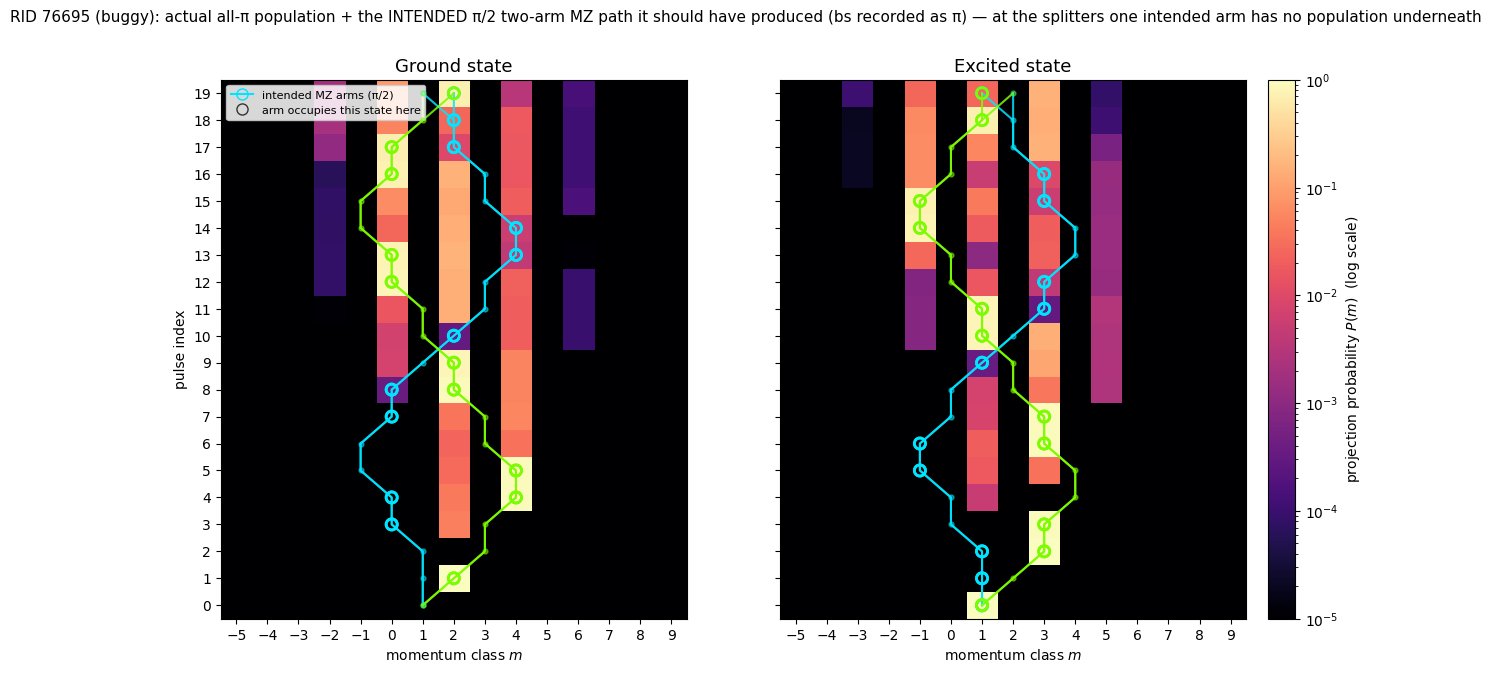

In [7]:
from matplotlib.colors import LogNorm  # noqa: E402
import matplotlib as mpl  # noqa: E402

FLOOR = 1e-5  # lower end of the log colour scale (5 decades down from ~1)
log_cmap = mpl.colormaps["magma"].copy()
log_cmap.set_bad(log_cmap(0.0))  # exact-zero cells render as the low-end colour

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
norm = LogNorm(vmin=FLOOR, vmax=1.0)
for ax, mat, title in (
    (axes[0], ground_mat, "Ground state"),
    (axes[1], excited_mat, "Excited state"),
):
    masked = np.where(mat > 0, mat, np.nan)  # keep true zeros out of the log
    im = ax.imshow(
        masked,
        aspect="auto",
        origin="lower",
        cmap=log_cmap,
        norm=norm,
        extent=[m_arr[0] - 0.5, m_arr[-1] + 0.5, -0.5, n_pulses - 0.5],
    )
    ax.set_title(title, fontsize=13)
    ax.set_xlabel("momentum class $m$")
    ax.set_xticks(m_arr)
axes[0].set_ylabel("pulse index")
axes[0].set_yticks(range(n_pulses))
overlay_intended_path(axes[0], axes[1], intended_arms)
cbar = fig.colorbar(im, ax=axes, fraction=0.035, pad=0.02)
cbar.set_label("projection probability $P(m)$  (log scale)")
fig.suptitle(
    "RID 76695 (buggy): actual all-π population + the INTENDED π/2 two-arm MZ "
    "path it should have produced (bs recorded as π) — at the splitters one "
    "intended arm has no population underneath",
    fontsize=11,
)
plt.show()

## Overall book-keeping: ground/excited split and total vs pulse

How the total ground and excited probability evolve, and confirmation that the
coherent projective readout conserves total probability (there are no clearouts
to remove any).

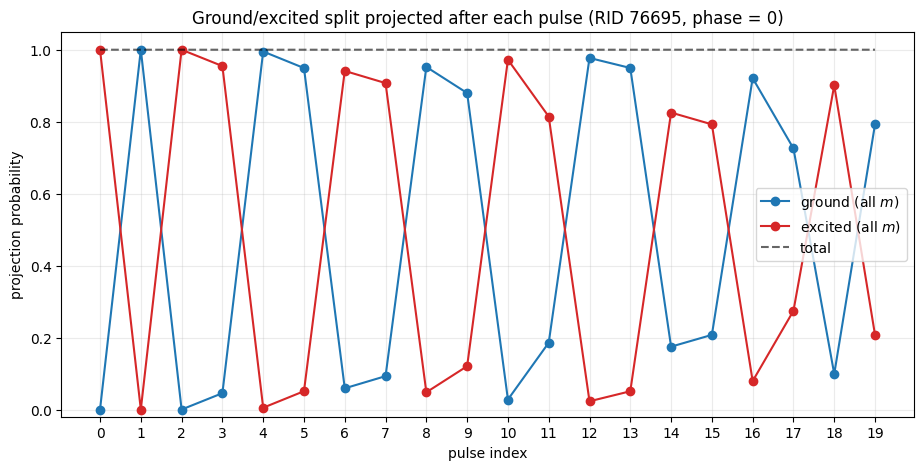

In [8]:
ground_total = ground_mat.sum(axis=1)
excited_total = excited_mat.sum(axis=1)
pulses = np.arange(n_pulses)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(pulses, ground_total, "-o", label="ground (all $m$)", color="tab:blue")
ax.plot(pulses, excited_total, "-o", label="excited (all $m$)", color="tab:red")
ax.plot(pulses, total_per_pulse, "--", label="total", color="k", alpha=0.6)
ax.set_xlabel("pulse index")
ax.set_ylabel("projection probability")
ax.set_xticks(pulses)
ax.set_ylim(-0.02, 1.05)
ax.grid(alpha=0.25)
ax.legend()
ax.set_title("Ground/excited split projected after each pulse (RID 76695, phase = 0)")
plt.show()

### Reading the map

* Pulse 0 is the 380 us velocity-selection pulse: it drives the selected slice
  from `|g, 0>` to `|e, +1>`, so straight after it the population sits almost
  entirely in the `m = +1` excited class.
* The launch ladder then walks the packet up in momentum; the excited/ground
  alternation is visible as population hops between adjacent `m` on each pulse.
* Any probability that appears in an `m` the intended path never visits is
  **leakage** -- off-resonant transfer that a perfect sequence would not
  produce. Those are the streaks to scrutinise.

Because the interferometry phase is zero here, the final-pulse recombination
lands in one particular set of ports; sweeping the scan phase (pulses 10-18
get `φ`, pulse 19 gets `4φ`) redistributes population **only among the
recombining classes** and leaves this leakage picture otherwise unchanged.

## Where the leakage comes from: per-pulse decomposition

The dump answers this completely. Every recorded duration is a full **π**
pulse at its beam's nominal π time (56 us up = `CLOCK_PI_TIME`, 67 us down =
`CLOCK_DOWN_PI_TIME` in icl_experiments `constants.py`; the 380 us slice is
also π at its lower Rabi frequency). The recorded frequencies form **two
interleaved combs**: pulses tuned to the rungs of the occupied path
(`m_g ∈ {0, 2, 4}` as the path walks), and pulses tuned to the rungs of the
interferometer's *other* arm — which in this record never holds population,
because there is no π/2 anywhere in the dump, so the sim walks a single path.

For each pulse we compare the rung it actually addresses (from its recorded
frequency) with the rung the population occupies, and evaluate the transfer
probability of the occupied rung with the sim's own 2x2 propagator
(`seq._transition_probability`). Alongside it: the closed-form generalised
Rabi formula for a square pulse of Rabi frequency $\Omega$ detuned by
$\delta$ from the occupied pair's resonance,

$$P = \frac{\Omega^2}{\Omega^2+\delta^2}\,
      \sin^2\!\bigl(\pi\sqrt{\Omega^2+\delta^2}\;T\bigr).$$

In [9]:
rec = sim.RECOIL_FREQUENCY_HZ
before_states = [
    snapshots[i][0] for i, e in enumerate(sequence) if isinstance(e, seq.Pulse)
]

print(
    f"{'p':>2} {'k':>2} {'addr m_g':>8} {'occupied':>9} {'P_occ':>10} "
    f"{'delta/rec':>9} {'P_formula':>10} {'role':>10}"
)
survival = 1.0
main = (0, "g")  # walk the occupied path by hand: (m, internal)
for p, pulse in enumerate(pulse_events):
    m_g_addr, _ = seq._addressed_momentum_classes(pulse)
    m_main, s_main = main
    is_ground = s_main == "g"
    m_g_main = m_main if is_ground else m_main - pulse.k
    P_occ = seq._transition_probability(m_main, is_ground, pulse)
    delta_hz = (m_g_addr - m_g_main) * 2 * pulse.k * rec
    W = np.sqrt(pulse.rabi_frequency**2 + delta_hz**2)
    P_formula = (pulse.rabi_frequency**2 / W**2) * np.sin(
        np.pi * W * pulse.duration
    ) ** 2
    resonant = abs(m_g_addr - m_g_main) < 0.5
    print(
        f"{p:>2} {pulse.k:>+2} {m_g_addr:>8.3f} {m_main:>+6d},{s_main} "
        f"{P_occ:>10.6f} {delta_hz / rec:>9.2f} {P_formula:>10.6f} "
        f"{'RESONANT' if resonant else 'other-arm':>10}"
    )
    if resonant:
        survival *= P_occ
        main = (m_g_main + pulse.k, "e") if is_ground else (m_g_main, "g")
    else:
        survival *= 1.0 - P_occ

final_ground, final_excited = coherent_populations_by_m(snapshots[-1][0])
final_main = (final_ground if main[1] == "g" else final_excited).get(main[0], 0.0)
print(f"\nsurvival product along the occupied path: {survival:.4f}")
print(f"sim final population in {main}:            {final_main:.4f}")

 p  k addr m_g  occupied      P_occ delta/rec  P_formula       role
 0 +1   -0.000     +0,g   1.000000     -0.00   1.000000   RESONANT
 1 -1    2.000     +1,e   1.000000     -0.00   1.000000   RESONANT
 2 +1    2.000     +2,g   1.000000      0.00   1.000000   RESONANT
 3 +1    0.003     +3,e   0.045454     -3.99   0.045454  other-arm
 4 -1    3.998     +3,e   0.999993      0.00   0.999993   RESONANT
 5 -1    0.003     +4,g   0.036041      7.99   0.036041  other-arm
 6 -1    3.998     +4,g   0.999994      0.00   0.999994   RESONANT
 7 -1    0.004     +3,e   0.036060      7.99   0.036060  other-arm
 8 +1    2.001     +3,e   0.999999      0.00   0.999999   RESONANT
 9 +1    0.004     +2,g   0.045290     -3.99   0.045290  other-arm
10 -1    2.001     +2,g   0.999998     -0.00   0.999998   RESONANT
11 +1    2.001     +1,e   0.046268      4.00   0.046268  other-arm
12 +1    0.004     +1,e   0.999982      0.01   0.999982   RESONANT
13 -1    3.999     +0,g   0.035929     -8.00   0.035929  othe

### Conclusion

* The 12 pulses tuned to the occupied rung transfer with infidelity
  **≤ 4e-5** (the few-tens-of-Hz residual detunings left by the anchoring /
  calibration fit are negligible). The resonant physics is essentially
  perfect, exactly as expected for a v = 0 atom with exact π areas.
* **All of the leakage comes from the 8 pulses tuned to the other arm's
  rungs.** Each is a square π pulse detuned by only 4 recoils (up beam,
  18.8 kHz) or 8 recoils (down beam, 37.7 kHz) from the occupied pair while
  carrying Ω = 8.9 / 7.5 kHz, so it off-resonantly drives the occupied rung
  with P ≈ 4.6% / 3.6% per pulse — the sim propagator matches the
  generalised-Rabi formula to all printed digits. Compounded over 8 pulses
  that predicts 28% total loss from the main path; the sim's 30% differs
  only because the leaked amplitudes are subsequently moved around (the
  other-arm pulses are *resonant* for them) and recombine coherently —
  that is why e.g. the `(+3, e)` parasite ends at 0.155, far more than one
  4% kick.
* So the leakage is **not** a tuning imperfection and no modelled-but-wrong
  shift is responsible: it is the inherent off-resonant response of square
  pulses whose Rabi frequency is comparable to the rung splitting
  (2·δ_rec = 9.4 kHz). The lab sequence model (`compile_sequence` in
  icl_experiments) book-keeps each pulse as acting only on its addressed
  pair, which is exactly the piece of physics this ignores.
* The sin² timing factor matters: the down-beam kick sits near its worst
  case (sin² = 0.95). A square π pulse also satisfies
  $\sqrt{\Omega^2+\delta^2}\,T = \text{integer}$ at "magic" durations that
  null the off-resonant kick entirely: for the 4-recoil spacing T = 46.0 or
  102.9 us (vs 56 us used), for the 8-recoil spacing T = 51.4 or 78.6 us
  (vs 67 us used). Detuning-selective durations — or shaped/ARP pulses —
  are the real fix.

## Why there is no π/2 in the record — and how the lab still saw fringes

The lab design *does* contain beamsplitters:
`symmetric_mach_zehnder_sequence` (icl_experiments `declarative-lmt` branch,
`repository/lib/lmt_sequence.py`) declares `bs1` and `bs2` as
`pi2(Beam.DOWN, ...)` events, and pulse 1 / pulse 19 of this dump are exactly
those events by their recorded frequencies. But this run used the
**global-parameter** mixin (`LMTGlobalParamsSymmetricMachZehnderMixin`), and
its duration binding, `lmt_global_duration_attr`, returns the shared
`lmt_up_duration` / `lmt_down_duration` handle for *every* full-intensity
pulse **regardless of `event.area`**. Neither the engine kernel nor
`_fire_pulse` scales duration (or DDS amplitude) by area — the π/2's
`EFFECT_SUPERPOSE` is recorded as intent metadata only. So bs1/bs2 were
physically fired for the full 67 us down-beam π time, exactly as the dump
records. (Per-pulse mode would have defaulted them to
`area / (2 rabi)` = half duration; global mode loses that.)

With bs1 executing as a π, the ideal walk is single-path — yet the lab saw
fringes when scanning the phase. The sim reproduces that too: the parasitic
amplitudes split off by the off-resonant kicks **are coherent**, are
resonantly transported by the very arm-B pulses that were meant for the real
second arm, and recombine at the final pulses. Sweeping φ (pulses 10-18
carry φ, pulse 19 carries 4φ) modulates those recombinations:

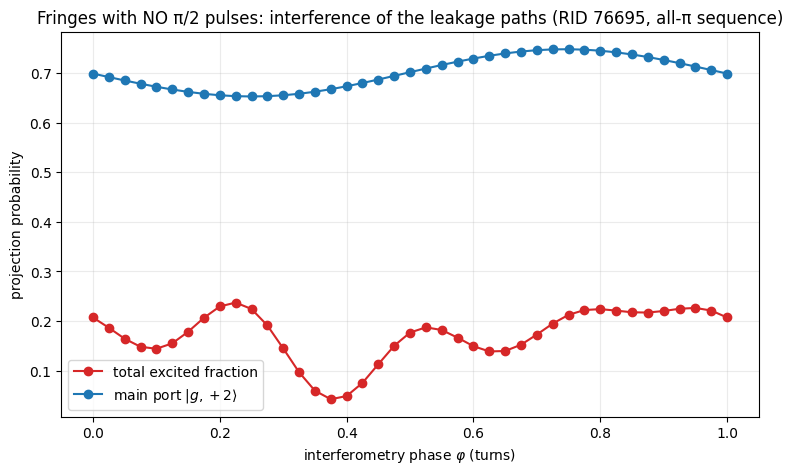

excited-fraction fringe: min 0.042, max 0.237, peak-to-peak 0.195


In [10]:
def run_at_phase(phi_turns):
    d = dataclasses.asdict(dump)
    turns = np.zeros(n_pulses)
    turns[10:19] = phi_turns
    turns[19] = 4 * phi_turns
    d["interferometry_phase_turns"] = turns
    _, sequence_phi = seq.build_sequence_from_lab_pulse_dump(
        **d,
        probe_induced_alpha_up=alpha,
        probe_induced_alpha_down=alpha,
        initial_velocity_z=v0,
    )
    final, _, _ = seq.run_pulse_sequence_in_borde_representation(
        sim.make_atom_states(c0=1, c1=0, initial_velocity_z=0.0),
        sequence_phi,
        initial_velocity_z=0.0,
        discard_threshold=1e-12,
    )
    return coherent_populations_by_m(final)


phis = np.linspace(0, 1, 41)
excited_fraction = []
port_g2 = []
for phi in phis:
    pg, pe = run_at_phase(phi)
    excited_fraction.append(sum(pe.values()))
    port_g2.append(pg.get(2, 0.0))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(phis, excited_fraction, "-o", label="total excited fraction", color="tab:red")
ax.plot(phis, port_g2, "-o", label="main port $|g, +2\\rangle$", color="tab:blue")
ax.set_xlabel("interferometry phase $\\varphi$ (turns)")
ax.set_ylabel("projection probability")
ax.grid(alpha=0.25)
ax.legend()
ax.set_title(
    "Fringes with NO π/2 pulses: interference of the leakage paths "
    "(RID 76695, all-π sequence)"
)
plt.show()

exc = np.array(excited_fraction)
print(
    f"excited-fraction fringe: min {exc.min():.3f}, max {exc.max():.3f}, "
    f"peak-to-peak {exc.max() - exc.min():.3f}"
)

The total excited fraction swings by ≈ 0.2 peak-to-peak, and the individual
leaked ports fringe with near-unity contrast — despite every pulse being a
π pulse. So the experimentally observed interference is entirely consistent
with this record: **the "leakage" paths are the only interferometer this
sequence has**. The fringe is also visibly non-sinusoidal (the recombining
paths carry different multiples of φ), which is a testable signature in the
lab data. Restoring the intended π/2 areas for the `bs1`/`bs2` events in
global-parameter mode (e.g. scaling the shared duration by `event.area`, or
giving π/2 events their own duration handle) should multiply the contrast
several-fold and make the fringe sinusoidal.